In [1]:
import pandas as pd
import numpy as np
from scipy import linalg
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# from modules.utils import ...
# from modules.ols import ...

In [ ]:
# timeline
D0 = '2005-01-01'
D1 = '2024-12-31'

# Data loading
data_ret: pd.DataFrame = pd.read_parquet("../data/return/return_fe.parquet")
data_mac: pd.DataFrame = pd.read_parquet("../data/macro/macro_fe.parquet")

In [70]:
size_n_style = ['SPY', 'QQQ', 'DIA', 'IWM', 'VTI', 'VUG', 'VTV', 'MDY', 'SCHD', 'VIG', 'USMV', 'QUAL',]
sect_n_indu = ['XLK', 'XLV', 'XLF', 'XLY', 'XLI', 'XLP', 'XLE', 'XLU', 'VNQ', 'XLB', 'XLC', 'IBB', 'SMH', 'HACK', 'ICLN', 'JETS', 'KRE', 'IYT', 'FDN', 'ARKK', 'XBI',]
bonds = ['AGG', 'TLT', 'IEF', 'SHV', 'TIP', 'LQD', 'HYG', 'MUB', 'BNDX', 'EMB', 'IAGG', 'VWOB',]
commodity = ['GLD', 'SLV', 'USO', 'UNG', 'DBC',]
crypto =  ['IBIT', 'ETHE',]
international = ['EFA', 'EEM', 'VXUS', 'IEMG', 'MCHI', 'EWJ', 'VGK', 'EWG', 'EWU', 'EWP', 'EWI', 'EIRL', 'EWY', 'EWT', 'EWH', 'EWA', 'EWS', 'EWZ', 'INDA', 'EWW', 'EIDO', 'THD', 'ENZL',]

universe = {
    "size_n_style": ['SPY', 'QQQ', 'DIA', 'IWM', 'VTI', 'VUG', 'VTV', 'MDY', 'SCHD', 'VIG', 'USMV', 'QUAL',],
    "sect_n_indu": ['XLK', 'XLV', 'XLF', 'XLY', 'XLI', 'XLP', 'XLE', 'XLU', 'VNQ', 'XLB', 'XLC', 'IBB', 'SMH', 'HACK', 'ICLN', 'JETS', 'KRE', 'IYT', 'FDN', 'ARKK', 'XBI',],
    "bonds": ['AGG', 'TLT', 'IEF', 'SHV', 'TIP', 'LQD', 'HYG', 'MUB', 'BNDX', 'EMB', 'IAGG', 'VWOB',],
    "commodity": ['GLD', 'SLV', 'USO', 'UNG', 'DBC',],
    "crypto":  ['IBIT', 'ETHE',],
    "international": ['EFA', 'EEM', 'VXUS', 'IEMG', 'MCHI', 'EWJ', 'VGK', 'EWG', 'EWU', 'EWP', 'EWI', 'EIRL', 'EWY', 'EWT', 'EWH', 'EWA', 'EWS', 'EWZ', 'INDA', 'EWW', 'EIDO', 'THD', 'ENZL',],
    "full_universe": size_n_style + sect_n_indu + bonds + commodity + crypto + international,
}

In [71]:
# model params
gamma = 100
halflife = 126
lookback = 504
horizon = 21
method = "N"
const_pred = 0.0

# asset selection
category = "full_universe"
assert category in universe, category

# feature selection
target = "MOM 1M VS"

features_ret = [
    "MOM 1M",  # Momentum
    "MOM 3M",
    "MOM 6M",
    # "MOM 1Y",
    # "MOM 2Y",
    # "MOM 1M VS",  # Vol-scaled momentum
    # "MOM 3M VS",
    # "MOM 6M VS",
    # "MOM 1Y VS",
    # "MOM 2Y VS",
    # "DD 3M",  # Drawdown / distance-to-high
    # "DD 6M",
    "DD 1Y",  # NOTE GOOD
    # "DD 2Y",
    # "MOM 1Y1M",  # Skip momentum
    # "MOM 1Y1W",
    # "MOM 6M1M",
    # "MOM 3M1W",
    # "MOM 1Y1M VS",  # Skip momentum vol scaled
    # "MOM 1Y1W VS",
    # "MOM 6M1M VS",
    # "MOM 3M1W VS",
    # "RCUM Z1M",  # RCUM z-scores
    # "RCUM Z3M",
    # "RCUM Z6M",
    # "RCUM Z1Y",
    # "VOLR 1M3M",  # Vol regime
    # "VOLR 1M1Y",
    # "VOLR 3M1Y",
    # "VOLR 1M2Y",
    # "VOLR 3M2Y",
    # "EWMA 1M",  # EWMA / vol scaling
    # "EWMA VOLR 1M1Y",
    # "EWMA VOLR 1M3M",
    # "MOM 1M1Y ACC",  # Acceleration
    # "MOM 1M6M ACC",
    # "TREND T3M",  # Trend strength
    # "TREND T6M",
    # "TREND T1Y",
    # "DLOGVOL 1M",  # Vol regime shifts
    # "DLOGVOL 3M",
    # "MOM 1W POS",  # Nonlinear short-horizon variants
    # "MOM 1W NEG",
    # "MOM 1M POS",
    # "MOM 1M NEG",
    # "MOM 1W VS CLIP3",
    # "MOM 1M VS CLIP3",
    # "MOM 1W VS * HI_VOL",
    # "MOM 1W VS * LO_VOL",
    # "MOM 1W VS * DD_STRESS",
    # "MOM 1W VS SQ",
    # "MOM1Y1M_DD3M",  # Structured interactions
    # "MOM6_MOM1WVS",
    # "MOM1Y1M_VOLR1M1Y",
    # "ACC_VOL1M",
]

features_mac = [
    "FFR CHG 1M",  # Policy  # NOTE GOOD
    # "FFR CHG 3M",
    # "FFR CHG 1Y",
    # "VIX LVL",  # Volatility
    # "VIX CHG 1M",
    # "VIX CHG 3M",
    # "VIX CHG 1Y",
    # "HYS CHG 1M",  # Credit
    # "HYS CHG 3M",
    # "HYS CHG 1Y",
    # "R10 CHG 1M",  # Real rates
    # "R10 CHG 3M",
    # "R10 CHG 1Y",
    # "OIL CHG 1M",  # Oil
    # "OIL CHG 3M",
    # "OIL CHG 1Y",
    "SLOPE 3M10Y",  # Curve level  # NOTE GOOD
    # "SLOPE 2Y10Y",
    # "SLOPE 3M10Y CHG 1M",  # Curve change
    # "SLOPE 3M10Y CHG 3M",
    # "SLOPE 3M10Y CHG 1Y",
    # "USD CHG 1M",  # USD / FX
    # "USD CHG 3M",
    # "USD CHG 1Y",
    # "CPI CHG 1Y",  # Inflation
    # "CPI ACC 3M",
    # "UNR LVL",  # Labor
    # "UNR CHG 3M",
    # "GDP CHG 1Y",  # Growth
    # "PCE CHG 1Y",
]

In [72]:
data, assets_remaining = ols.preprocess_alpha_data(
    data_ret=data_ret,
    data_mac=data_mac,
    assets=universe[category],
    features_ret=features_ret,
    features_mac=features_mac,
    target=target,
    )

xdata, ydata = ols.xy_split(
    data=data, 
    target=target,
    features_ret=features_ret,
    horizon=horizon,
    )

L_graph = ols.laplacian_graph(
    file_path="../data/other/laplace.csv",
    assets=assets_remaining,
    attributes=["Asset Class", "Geography"],
    w_edges=None,  # np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
    )

# Run alpha predictor backtest
df_prd, df_ref, theta = ols.alpha_predictor(
    xdata, ydata, L_graph,
    gamma=gamma,
    halflife=halflife,
    lookback=lookback,
    horizon=horizon,
    method=method,
    const_pred=const_pred,
)
assert df_prd.shape == df_ref.shape == theta.shape[:2]

# save_alpha_result(
#     file_path="../results/alpha/method_ols.csv",
#     df_prd=df_prd,                              # Derive Scores
#     df_ref=df_ref,
#     gamma=gamma,                                # Log Params
#     halflife=halflife, 
#     lookback=lookback, 
#     horizon=horizon, 
#     method=method, 
#     const_pred=const_pred,
#     xshape=xdata.shape,                         # Log Metadata 
#     yshape=ydata.shape,
#     assets="|".join(assets_remaining),
#     features_mac="|".join(features_mac),
#     features_ret="|".join(features_ret),
#     target=target,
# )

r2    = utils.r2_score(df_prd, df_ref).sort_values()
nrmse = utils.nrmse_score(df_prd, df_ref).sort_values()
icp = utils.ic_score(df_prd, df_ref, method="pearson")
ics = utils.ic_score(df_prd, df_ref, method="spearman")
t_icp = utils.t_test(icp, mu_h0=0.0)
t_ics = utils.t_test(ics, mu_h0=0.0)

print(f"R2:    {r2.mean().round(4):1.4f}")
print(f"NRMSE: {nrmse.mean().round(4):1.4f}")
print(f"IC Pearson:  {icp.mean():1.5f}, T-test : {t_icp:1.5f}")
print(f"IC Spearman: {ics.mean():1.5f}, T-test : {t_ics:1.5f}")

R2:    -0.2050
NRMSE: 1.0976
IC Pearson:  0.05511, T-test : 10.69217
IC Spearman: 0.06150, T-test : 12.62099


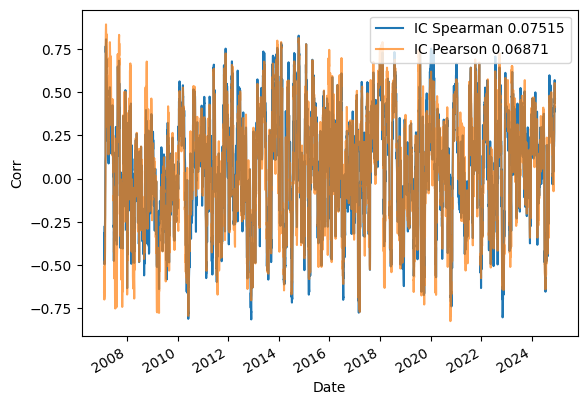

In [ ]:
# alpha predictor ranking
ics.plot(label=f"IC Spearman {ics.mean():1.5f}",alpha=1.0,xlabel="Time")
icp.plot(label=f"IC Pearson {icp.mean():1.5f}",alpha=0.7,ylabel="Corr")
plt.legend()
plt.show()

np.float64(0.9999999999999998)

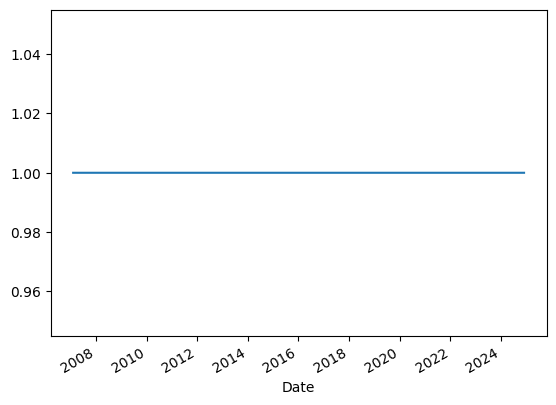

In [153]:
ics_perfect = utils.ic_score(df_ref, df_ref, method="spearman")
ics_perfect.plot()
ics_perfect.mean()

np.float64(0.13585040717527105)

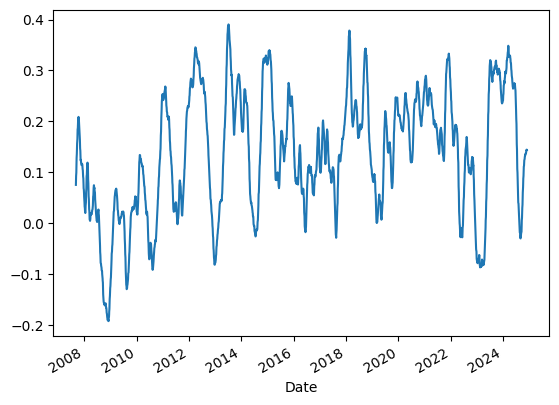

In [156]:
# ranking according to rolling mean (non overlap)
df_mean = df_ref.rolling(2*504, min_periods=0).mean().shift(21)
ics_mean = utils.ic_score(df_mean, df_ref, method="spearman")
ics_mean.rolling(126).mean().plot()
ics_mean.mean()

In [134]:
df_mean

Ticker,AGG,DIA,EEM,EFA,EWA,EWG,EWH,EWI,EWJ,EWP,...,VTI,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2007-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,-1.579400,1.156819,-0.145918,0.437461,0.305404,0.440149,-0.910451,0.957628,0.161458,0.697237,...,1.574483,0.560765,1.191049,1.397621,1.108663,1.516229,0.546698,0.541228,0.659830,1.019025
2024-11-25,-1.583925,1.161077,-0.156848,0.426510,0.300217,0.434698,-0.923837,0.942515,0.155195,0.686717,...,1.576185,0.558009,1.191600,1.400934,1.109566,1.516349,0.546511,0.543527,0.655955,1.025576
2024-11-26,-1.587798,1.164163,-0.168899,0.413976,0.293458,0.428130,-0.935646,0.925400,0.147123,0.674487,...,1.577517,0.552955,1.191235,1.402846,1.109667,1.516898,0.546807,0.546807,0.652923,1.032413


np.float64(0.1572922904723545)

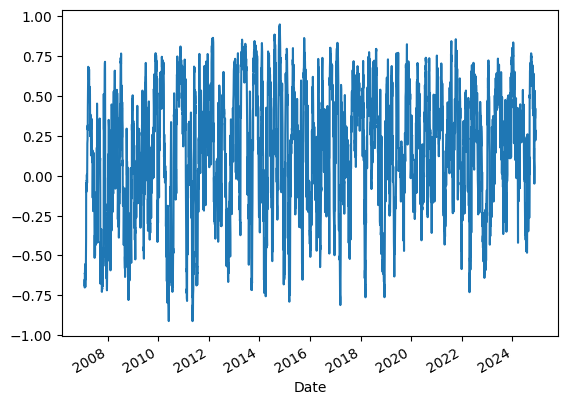

In [119]:
# ranking according to mean of entire period
df_mean = pd.DataFrame(
    np.tile(df_ref.mean(axis=0).values, (df_ref.shape[0], 1)),
    index=df_prd.index,
    columns=df_prd.columns
)
ics_mean_global = utils.ic_score(df_mean, df_ref, method="spearman")
ics_mean_global.plot()
ics_mean_global.mean()

np.float64(-0.0002954639624316944)

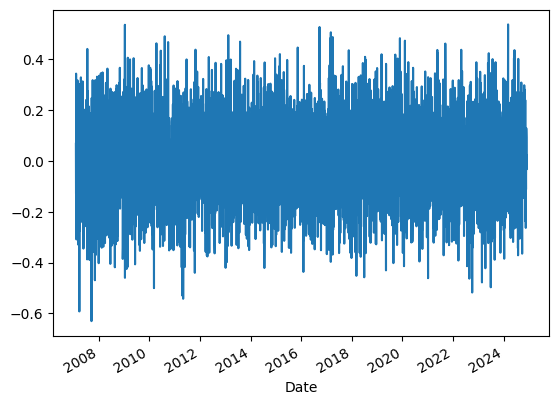

In [155]:
# random ranking
df_rng = pd.DataFrame(np.random.random(df_prd.shape), columns=df_prd.columns, index=df_prd.index)
ics_rng = utils.ic_score(df_rng, df_ref, method="spearman")
ics_rng.plot()
ics_rng.mean()

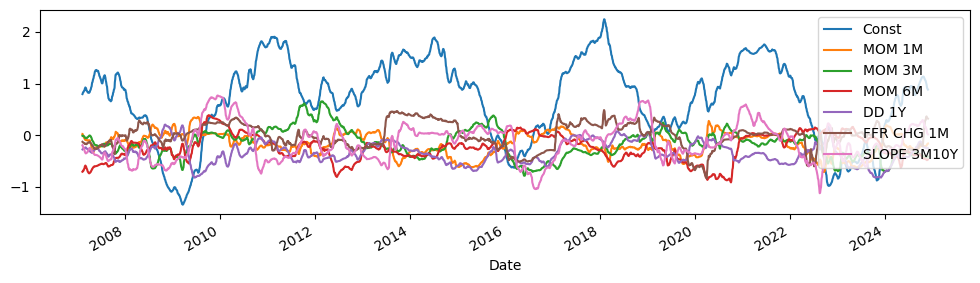

In [74]:
# plotting thetas over time
features_all = ["Const"] + features_ret + features_mac
pd.DataFrame(theta.mean(axis=1), columns=features_all, index=df_ref.index).plot(figsize=(12,3))
plt.show()

In [75]:
# alpha = df_prd
# alpha.to_parquet("../data/alpha/method_ols.parquet")